In this notebook, we attempt to model "award-worthiness" using linear, ridge, and lasso regression

In [476]:
# standard imports
import pandas as pd
import numpy as np
import sys

sys.path.append("..")

In [477]:
shortlists = pd.read_csv("../data/train_novels.csv")
shortlists.head()

,author_qid,pubDate,goodreads_id,title,authorLabel,work_qid,year,n_nom,n_win,awards_as_of_year,age,birth_country,gender,topicality,max,count,median
0,Q1006918,1965-01-01T00:00:00Z,NaN,The Ship That Sailed the Time Stream,G. C. Edmondson,Q122452512,1966,1,0,0,44.0,United States,male,0.219992,NaN,NaN,NaN
1,Q1029497,2006-11-28T00:00:00Z,NaN,Carnival,Elizabeth Bear,Q25217435,2007,2,0,1,36.0,United States,female,0.169624,NaN,NaN,NaN
2,Q1029497,2007-08-01T00:00:00Z,NaN,Undertow,Elizabeth Bear,Q131381664,2008,1,0,4,37.0,United States,female,0.245872,NaN,NaN,NaN
3,Q1029497,2010-02-20T00:00:00Z,NaN,Chill,Elizabeth Bear,Q131382134,2011,1,0,13,40.0,United States,female,-0.195356,NaN,NaN,NaN
4,Q1029497,2011-02-22T00:00:00Z,NaN,Grail,Elizabeth Bear,Q131382162,2012,1,0,15,41.0,United States,female,0.182915,NaN,NaN,NaN


**Data preparation**

In [478]:
#linprepare_df is similar to what prepare_df does from models.prepare, but we do not merge authors together because this turns some features (e.g. gender, age) into list objects. 
#linprepare_df also one-hot encodes gender and birth country

from models.linearprepare import linprepare_df

df_train = linprepare_df(shortlists)

df_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 55 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   author_qid                                1513 non-null   object 
 1   goodreads_id                              493 non-null    float64
 2   title                                     1513 non-null   object 
 3   authorLabel                               1513 non-null   object 
 4   work_qid                                  1513 non-null   object 
 5   year                                      1513 non-null   int64  
 6   n_win                                     1513 non-null   int64  
 7   awards_as_of_year                         1513 non-null   int64  
 8   age                                       1513 non-null   float64
 9   topicality                                1513 non-null   float64
 10  max_bestseller_rank                 

In [479]:
#removing the rest of the non-numerical features and "month", which contains null entries

safe_to_drop = ["author_qid", "goodreads_id", "title", "authorLabel", "work_qid", "month"]
df_train.drop(columns=safe_to_drop, inplace=True)


In [480]:
#confirming we have no columns with null entries

df_train.isnull().sum()

year                                        0
n_win                                       0
awards_as_of_year                           0
age                                         0
topicality                                  0
max_bestseller_rank                         0
months_on_bestseller                        0
median_bestseller_rank                      0
gender_genderfluid                          0
gender_male                                 0
gender_non-binary gender                    0
gender_trans man                            0
gender_trans woman                          0
birth_country_Australia                     0
birth_country_Austria                       0
birth_country_Barbados                      0
birth_country_Canada                        0
birth_country_Cuba                          0
birth_country_Czech Republic                0
birth_country_Finland                       0
birth_country_France                        0
birth_country_Germany             

In [481]:
X = df_train.copy()
y = X.pop("n_win")

**Model 1: Linear regression**

Step 1: Cross-validation

In [482]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, root_mean_squared_error

#setting up the scorer

neg_rmse_linear = make_scorer(root_mean_squared_error, greater_is_better=False)

#setting up our model and cross-validation RMSE scores

linear = LinearRegression()
cv_scores_linear = cross_val_score(linear, X, y, cv=5, scoring=neg_rmse_linear)

print(f"Cross-validated RMSE scores per fold: {-cv_scores_linear}")
print(f"Mean cross-validated RMSE: {-cv_scores_linear.mean():.4f}")
print(f"Std Dev cross-validated RMSE: {cv_scores_linear.std():.4f}")

Cross-validated RMSE scores per fold: [0.47413079 0.40570728 0.37307512 0.41704912 0.36402768]
Mean cross-validated RMSE: 0.4068
Std Dev cross-validated RMSE: 0.0390


Step 2: Fitting our model and computing RMSE and R^2 score

In [483]:
from sklearn.metrics import r2_score

linear.fit(X, y)
y_pred_linear = linear.predict(X)

rmse_linear = root_mean_squared_error(y, y_pred_linear)
r2_linear = r2_score(y, y_pred_linear)

print(f"Linear regression RMSE: {rmse_linear:.4f}")
print(f"Linear regression R² score: {r2_linear:.4f}")

Linear regression RMSE: 0.3938
Linear regression R² score: 0.3030


Step 3: Plotting our results

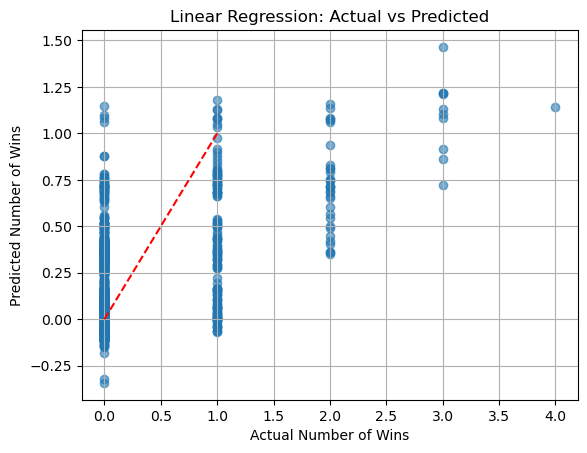

In [484]:
import matplotlib.pyplot as plt

plt.scatter (y, y_pred_linear, alpha=0.6)
plt.xlabel("Actual Number of Wins")
plt.ylabel("Predicted Number of Wins")
plt.title("Linear Regression: Actual vs Predicted")
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.grid()
plt.show()

**Model 2: Ridge Regression**

Step 1: Cross-validation

In [485]:
#computing optimal alpha via cross-validation
from sklearn.linear_model import Ridge, RidgeCV

alphas = np.logspace(-4, 4, 50)  
cv_ridge = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error', cv=5)
cv_ridge.fit(X, y)

print(f"Best alpha: {cv_ridge.alpha_}")

Best alpha: 35.564803062231285


In [486]:
#setting up cross-validation RMSE scores

neg_rmse_scores_ridge = cross_val_score(cv_ridge, X, y, cv=5, scoring='neg_root_mean_squared_error')

rmse_scores_ridge = -neg_rmse_scores_ridge

print("Cross-validated RMSE scores per fold:", rmse_scores_ridge)
print(f"Mean cross-validated RMSE: {rmse_scores_ridge.mean():.4f}")
print(f"Std Dev cross-validated RMSE: {rmse_scores_ridge.std():.4f}")

Cross-validated RMSE scores per fold: [0.47222183 0.39780423 0.36940089 0.41385596 0.35437009]
Mean cross-validated RMSE: 0.4015
Std Dev cross-validated RMSE: 0.0410


Step 2: Fitting our model and computing RMSE and R^2 score

In [487]:
#initializing ridge regression with optimal alpha
ridge = Ridge(alpha=cv_ridge.alpha_)  

#fitting our model and 

ridge.fit(X, y)

y_pred_ridge = ridge.predict(X)

rmse_ridge = root_mean_squared_error(y, y_pred_ridge)
r2_ridge = r2_score(y, y_pred_ridge)

print(f"Ridge regression RMSE: {rmse_ridge:.4f}")
print(f"Ridge regression R² score: {r2_ridge:.4f}")

Ridge regression RMSE: 0.3966
Ridge regression R² score: 0.2930


Step 3: Plotting our results

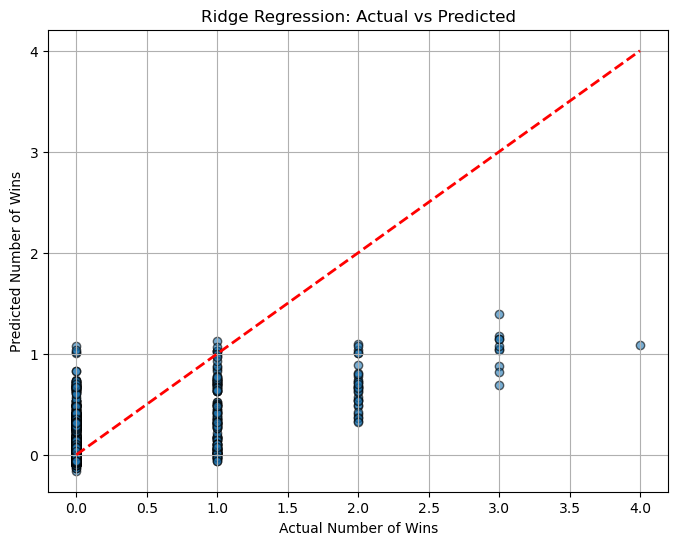

In [488]:
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred_ridge, alpha=0.6, edgecolor='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual Number of Wins")
plt.ylabel("Predicted Number of Wins")
plt.title("Ridge Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

Model 3: Lasso Regression

Step 1: Cross-validation

In [489]:
#computing optimal alpha via cross-validation

from sklearn.linear_model import LassoCV

cv_lasso = LassoCV(alphas=None, cv=5, random_state=42, max_iter=10000)  
cv_lasso.fit(X, y)
print(f"Best alpha: {cv_lasso.alpha_:.6f}")


Best alpha: 0.005556


In [490]:
#computing cross-validation RMSE scores

neg_rmse_scores_lasso = cross_val_score(cv_lasso, X, y, cv=5, scoring='neg_root_mean_squared_error')

rmse_scores_lasso = -neg_rmse_scores_lasso

print("Cross-validated RMSE scores per fold:", rmse_scores_lasso)
print(f"Mean cross-validated RMSE: {rmse_scores_lasso.mean():.4f}")
print(f"Std Dev cross-validated RMSE: {rmse_scores_lasso.std():.4f}")

Cross-validated RMSE scores per fold: [0.47044281 0.39496985 0.36790583 0.40987846 0.35157737]
Mean cross-validated RMSE: 0.3990
Std Dev cross-validated RMSE: 0.0411


Step 2: Fitting our model and computing RMSE and R^2 score

In [491]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=cv_lasso.alpha_)  
lasso.fit(X, y)
y_pred_lasso = lasso.predict(X)

r2_lasso = r2_score(y, y_pred_lasso)
rmse_lasso = root_mean_squared_error(y, y_pred_lasso)

print(f"Lasso regression RMSE: {rmse_lasso:.4f}")
print(f"Lasso regression R² Score: {r2_lasso:.4f}")

Lasso regression RMSE: 0.3973
Lasso regression R² Score: 0.2903


Step 3: Plotting our results

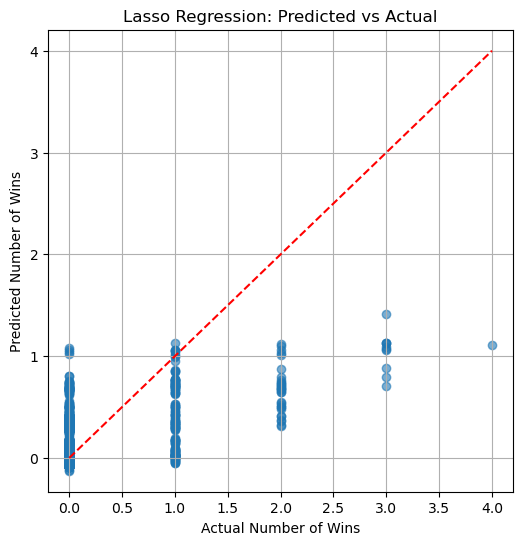

In [492]:
plt.figure(figsize=(6,6))
plt.scatter(y, y_pred_lasso, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  

plt.xlabel("Actual Number of Wins")
plt.ylabel("Predicted Number of Wins")
plt.title("Lasso Regression: Predicted vs Actual")
plt.grid(True)
plt.show()


**Model 4: Naive model**

Step 1: Running our model and computing RMSE and R^2 score

In [493]:
from models.naive import naive_win_counts

# aligning indices
df_train = df_train.reset_index(drop=True)
df_train["naive_wins"] = naive_win_counts(df_train).reset_index(drop=True)

rmse_naive = root_mean_squared_error(df_train["n_win"], df_train["naive_wins"])
r2_naive = r2_score(df_train["n_win"], df_train["naive_wins"])

print(f"Naive model RMSE: {rmse_naive:.4f}")
print(f"Naive model R² score: {r2_naive:.4f}")

Naive model RMSE: 0.5896
Naive model R² score: -0.5629


**Comparing models**

In [494]:
# Example performance values — replace with your actual ones
performance = pd.DataFrame({
    "Model": ["Naive", "Linear", "Ridge", "Lasso"],
    "RMSE": [rmse_naive, rmse_linear, rmse_ridge, rmse_lasso],
    "R2": [r2_naive, r2_linear, r2_ridge, r2_lasso]
})


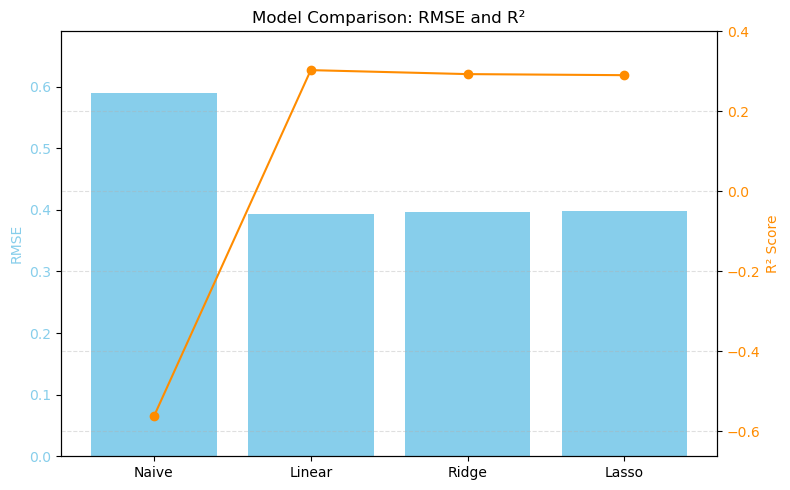

In [495]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# bar plot for RMSE
ax1.bar(performance["Model"], performance["RMSE"], color="skyblue", label="RMSE")
ax1.set_ylabel("RMSE", color="skyblue")
ax1.tick_params(axis='y', labelcolor="skyblue")
ax1.set_ylim(0, max(performance["RMSE"]) + 0.1)

# create a second y-axis for R²
ax2 = ax1.twinx()
ax2.plot(performance["Model"], performance["R2"], color="darkorange", marker="o", label="R²")
ax2.set_ylabel("R² Score", color="darkorange")
ax2.tick_params(axis='y', labelcolor="darkorange")
ax2.set_ylim(min(performance["R2"]) - 0.1, 0.4)

plt.title("Model Comparison: RMSE and R²")
fig.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.show()
